In [1]:
import pandas as pd

In [2]:
d=pd.read_csv("Red.csv")

In [3]:
d

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016
...,...,...,...,...,...,...,...,...
8661,6th Sense Syrah 2016,United States,Lodi,Michael David Winery,3.8,994,16.47,2016
8662,Botrosecco Maremma Toscana 2016,Italy,Maremma Toscana,Le Mortelle,4.0,995,20.09,2016
8663,Haut-Médoc 2010,France,Haut-Médoc,Château Cambon La Pelouse,3.7,996,23.95,2010
8664,Shiraz 2019,Australia,South Eastern Australia,Yellow Tail,3.5,998,6.21,2019


In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8666 entries, 0 to 8665
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             8666 non-null   object 
 1   Country          8666 non-null   object 
 2   Region           8666 non-null   object 
 3   Winery           8666 non-null   object 
 4   Rating           8666 non-null   float64
 5   NumberOfRatings  8666 non-null   int64  
 6   Price            8666 non-null   float64
 7   Year             8666 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 541.8+ KB


In [7]:
import numpy as np
np.mean(d["Rating"])

np.float64(3.8903415647357487)

In [10]:
d["NumberOfRatings"].unique()

array([ 100, 1000, 1001, ...,  996,  998,  999], shape=(1563,))

In [11]:
d.columns[d.isnull().any()]

Index([], dtype='object')

In [13]:
nd=d.select_dtypes(["float64","int64"])
nd

,Rating,NumberOfRatings,Price
0,4.2,100,95.00
1,4.3,100,15.50
2,3.9,100,7.45
3,3.5,100,8.72
4,3.9,100,29.15
...,...,...,...
8661,3.8,994,16.47
8662,4.0,995,20.09
8663,3.7,996,23.95
8664,3.5,998,6.21


In [14]:
nd.kurt()

Rating               0.002640
NumberOfRatings    126.933983
Price              353.421256
dtype: float64

In [15]:
nd.corr()

,Rating,NumberOfRatings,Price
Rating,1.000000,0.075216,0.451060
NumberOfRatings,0.075216,1.000000,0.006407
Price,0.451060,0.006407,1.000000


In [16]:
x=nd[["Rating","NumberOfRatings"]]
y=nd["Price"]

In [17]:
from sklearn.model_selection import  train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [19]:
x_train

,Rating,NumberOfRatings
8577,3.8,97
2988,4.0,253
5241,3.7,42
107,4.1,103
7181,4.3,672
...,...,...
5734,4.3,473
5191,4.1,42
5390,3.6,44
860,3.5,128


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
from sklearn.metrics import r2_score

In [22]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pre=lr.predict(x_test)
y_pre

array([-22.60614686,   3.46746835,   2.48433441, ...,  28.99650445,
        28.86638379,  28.97722732], shape=(1734,))

In [24]:
lr.coef_

array([ 1.27295782e+02, -2.40964201e-03])

In [25]:
lr.intercept_

np.float64(-454.66481817561726)

In [26]:
r2_score(y_test,y_pre)

0.2719146414373972

In [28]:
i=[[4.0,70]]
lr.predict(i)

C:\Users\gavas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([54.3496367])

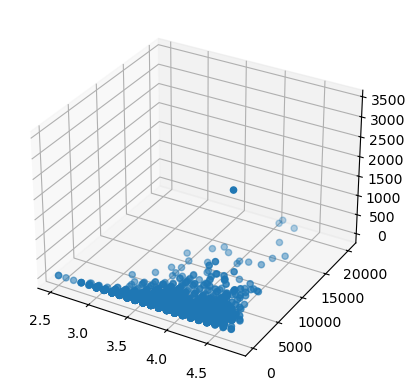

In [30]:
import matplotlib.pyplot as plt
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")

ax.scatter(x["Rating"],x["NumberOfRatings"],y)